In [1]:
def getLineAndCol(Npad):
    line, col = Npad, 1
    while(line > 8):
        line = line - 8
    while(Npad > 8):
        Npad = Npad - 8
        col = col + 1

    return line, col   

In [2]:
getLineAndCol(9)

(1, 2)

In [3]:
from math import sqrt, atan, asin, pi

Lx = 15 #cm
Ly = 19 #cm
H = 202.6 #cm

def getDeltaX(col_pad1, col_pad2):
    return (col_pad1 - col_pad2 - 1)*Lx+2*np.random.rand()*Lx

def getDeltaY(lin_pad1, lin_pad2):
    return (lin_pad1 - lin_pad2 -1)*Ly+2*np.random.rand()*Ly

def getZen(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    return (180 * atan(diag / H)/pi)

def getAzi(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    if(diag > 0):
        azi = asin(deltaY/diag)
        if (deltaX) <= 0.:
            azi = pi - azi
        if azi < 0 and (deltaX) > 0.:
            azi = 2*pi + azi
        return 180*azi/pi
    else:
        azi=np.random.rand()*360.
        return azi

In [4]:
import pandas as pd
import numpy as np

def calcAngles(Npad1, Npad2):
    lin_pad1, col_pad1 = getLineAndCol(Npad1)
    lin_pad2, col_pad2 = getLineAndCol(Npad2)

    deltaX = getDeltaX(col_pad1, col_pad2)
    deltaY = getDeltaY(lin_pad1, lin_pad2)

    zen = getZen(deltaX, deltaY)
    azi = getAzi(deltaX, deltaY)
    
    return azi, zen

In [5]:
calcAngles(2, 14)

(264.4181998622119, 19.400608254814735)

In [6]:
from math import sqrt, atan, asin, log10, pi
from matplotlib import pyplot as plt
import numpy as np 

Lx = 15 #cm
Ly = 19 #cm
H = 202.6 #cm

def espelhar(Npad):
    if(0<Npad<65):    
        line, col = Npad, 1
        while(line > 8):
            line = line - 8
        while(Npad > 8):
            Npad = Npad - 8
            col = col + 1
        col=8-col+1
        espelhada=(col-1)*8+line    
        return espelhada 
    else:
        return Npad


def getNpads(arquivo):
    nPads_RPC1,nPads_RPC2,nPads_RPC3=[],[],[]
    binario=open(arquivo, 'rb')   #lê o arqmyfile.binuivo binário
    array = np.fromfile(binario, dtype=np.uint8) #array para o qual os bytes do arquivo serão lidos
    tamanho=len(array) #tamanho do array lido
    indice=0 #indice usado para varrer o array
    while(indice<tamanho):     # converte de uint8_t para int comum e separa as pads de cada RPC em um array diferente
        pad1=int(array[indice+1])
        pad2=int(array[indice+2])
        nPads_RPC1.append(pad1)     
        nPads_RPC2.append(pad2)
        indice+=3
    return nPads_RPC1, nPads_RPC2


def getLineAndCol(Npad):
    line, col = Npad, 1
    while(line > 8):
        line = line - 8
    while(Npad > 8):
        Npad = Npad - 8
        col = col + 1

    return line, col   

def getDeltaX(col_pad1, col_pad2):
    return (col_pad1 - col_pad2-1)*Lx+2*np.random.rand()*Lx

def getDeltaY(lin_pad1, lin_pad2):
    return (lin_pad1 - lin_pad2-1)*Ly+2*np.random.rand()*Ly

def getZen(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    return (180 * atan(diag / H)/pi)

def getAzi(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    if(diag > 0):
        azi = asin(deltaY/diag)
        if (deltaX) <= 0.:
            azi = pi - azi
        if azi < 0 and (deltaX) > 0.:
            azi = 2*pi + azi
        return 180*azi/pi
    else:
        azi=random.rand()*360
        return azi

def calcAngles(Npad1, Npad2):
    lin_pad1, col_pad1 = getLineAndCol(Npad1)
    lin_pad2, col_pad2 = getLineAndCol(Npad2)

    deltaX = getDeltaX(col_pad1, col_pad2)
    deltaY = getDeltaY(lin_pad1, lin_pad2)

    zen = getZen(deltaX, deltaY)
    azi = getAzi(deltaX, deltaY)
    
    return azi, zen

In [7]:
nPads_RPC2, nPads_RPC1 = getNpads('EAFEXP_2024_09_28.bin')

In [9]:
import ROOT
from ROOT import TH2D, TCanvas

azimutal, zenital = [], []
line_RPC1, col_RPC1 = [], []
line_RPC2, col_RPC2 = [], []
validpads1,validpads2=[],[]

h2_top = TH2D("h2_top", "", 8, 0.5, 8.5, 8, 0.5, 8.5)

for i in range(len(nPads_RPC1)):
    nPad1=nPads_RPC1[i]
    nPad2=nPads_RPC2[i]
    if(0<nPad1<65 and 0<nPad2<65):
        validpads1.append(nPad1)
        validpads2.append(nPad2)
        line1, col1 = getLineAndCol(nPad1)
        line_RPC1.append(line1)
        col_RPC1.append(col1)
        line2, col2 = getLineAndCol(nPad2)
        line_RPC2.append(line2)
        col_RPC2.append(col2)
        azi,zen=calcAngles(nPad1,nPad2)    
        azimutal.append(azi)
        zenital.append(zen)
    h2_top.Fill(col1, line1)
    
Npads_1, Npads_2 = np.array(validpads1), np.array(validpads2)
Azimute, Zenite = np.array(azimutal), np.array(zenital)

Welcome to JupyROOT 6.30/02


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TROOT::Append>: Replacing existing TH1: hist1 (Potential memory leak).


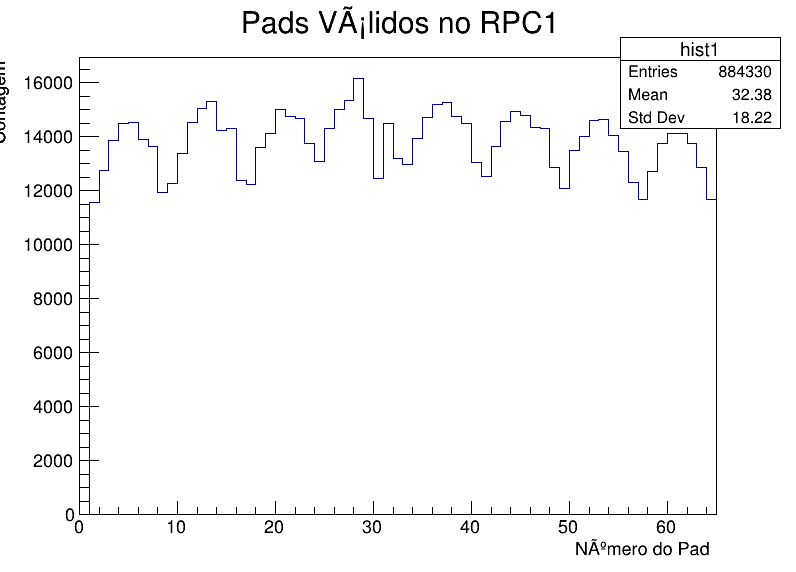

In [17]:
import ROOT

c1 = ROOT.TCanvas("c1", "Histograma", 800, 600)
hist1 = ROOT.TH1F("hist1", "Pads Válidos no RPC1;Número do Pad;Contagem", 65, 0, 65)

for number in Npads_1:  
    hist1.Fill(number)

hist1.Draw()
c1.Draw()